# Un pico sobre el fondo

### Boletín II, ejercicio 5 (guiado): $H \to Z + Z^* \to 4$ leptones con los datos abiertos de CMS

Jose A. Hernando

*Departamento de Física de Partículas. Universidade de Santiago de Compostela*

In [1]:
# Configuración e imports
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm

# Los datos están en datos/, junto a este cuaderno; si no (Google Colab), se leen de GitHub
URL = 'https://raw.githubusercontent.com/jahernando/USC-FNyP/main/notebooks/bols/datos/'

def lee(nombre):
    try:
        return pd.read_csv('datos/' + nombre, comment='#')
    except FileNotFoundError:
        return pd.read_csv(URL + nombre, comment='#')

# Colores Okabe-Ito (legibles con daltonismo), y además tramas distintas
COL = {'zz': '#56B4E9', 'z_x': '#E69F00', 'ttbar': '#999999', 'higgs': '#D55E00'}

## Objetivos

* Calcular la **masa invariante** de cuatro leptones a partir de sus cuadrimomentos medidos.

* Reconstruir los dos bosones intermedios, $Z$ y $Z^*$, emparejando los leptones.

* Construir el espectro de $m_{4l}$ y compararlo con lo que se **espera del fondo**.

* Contar el exceso y estimar su **significación** con la distribución de Poisson.

Es la versión «de verdad» del ejercicio 4: allí se leía la gráfica de ATLAS; aquí la haces tú con los
sucesos de CMS.

## Los datos

CMS publica parte de sus datos en el [CERN Open Data Portal](https://opendata.cern.ch). Usamos los
sucesos con **cuatro leptones aislados** (dos pares de carga opuesta y mismo sabor: $4\mu$, $4e$ o
$2e2\mu$) de 2011 ($\sqrt s = 7$ TeV, 2.3 $\mathrm{fb}^{-1}$) y 2012 ($\sqrt s = 8$ TeV, 11.6 $\mathrm{fb}^{-1}$),
seleccionados por el ejemplo de análisis de CMS [Jomhari, Geiser y Bin Anuar,
[DOI:10.7483/OPENDATA.CMS.JKB8.RR42](https://doi.org/10.7483/OPENDATA.CMS.JKB8.RR42)].

Cada fila es un suceso. Para cada leptón $i = 1, \dots, 4$: `PIDi` (11 electrón, 13 muón; negativo,
antipartícula), `Ei`, `pxi`, `pyi`, `pzi` (GeV) y `Qi` (carga). Las últimas columnas, `mZ1`, `mZ2` y
`M`, son el resultado del análisis de CMS: las usaremos solo para comprobar el nuestro.

El fichero `higgs_4l_cms_esperados.csv` da, por intervalos de 3 GeV de $m_{4l}$, los sucesos que se
esperan de cada proceso según la simulación, ya normalizados a la luminosidad de los datos.

## La masa invariante de cuatro leptones

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Los datos y la masa invariante</b></p>

1. Lee `higgs_4l_cms.csv`. ¿Cuántos sucesos hay de cada año y de cada canal?
2. Escribe una función que calcule la masa invariante de un conjunto de partículas a partir de sus
   cuadrimomentos, $m^2 = \left(\sum E_i\right)^2 - \left|\sum \vec p_i\right|^2$.
3. Calcula $m_{4l}$ para todos los sucesos y compárala con la columna `M`.
4. ¿Se puede despreciar la masa de los leptones? Compruébalo con $E^2 - p^2$ de cada leptón.

</div>

In [2]:
datos = lee('higgs_4l_cms.csv')
print('sucesos:', len(datos))
print(datos.groupby(['periodo', 'canal']).size())

def cuadrimomento(df, i):
    # (E, px, py, pz) del leptón i, una fila por suceso
    return df[['E{}'.format(i), 'px{}'.format(i), 'py{}'.format(i), 'pz{}'.format(i)]].to_numpy()

def masa_invariante(*ps):
    p = sum(ps)
    m2 = p[:, 0]**2 - np.sum(p[:, 1:]**2, axis=1)
    return np.sqrt(np.clip(m2, 0, None))

leps = [cuadrimomento(datos, i) for i in range(1, 5)]
m4l  = masa_invariante(*leps)

print('máxima diferencia con M      = {:.3f} GeV'.format(np.max(np.abs(m4l - datos['M']))))
m2_lep = np.concatenate([l[:, 0]**2 - np.sum(l[:, 1:]**2, axis=1) for l in leps])
print('E^2 - p^2 de los leptones    : entre {:.2f} y {:.2f} GeV^2'.format(m2_lep.min(), m2_lep.max()))

sucesos: 278
periodo  canal
2011     2e2mu     13
         4e         7
         4mu       18
2012     2e2mu    104
         4e        41
         4mu       95
dtype: int64
máxima diferencia con M      = 0.006 GeV
E^2 - p^2 de los leptones    : entre -0.41 y 0.88 GeV^2


<details>
<summary><b>Solución</b></summary>

1. 278 sucesos: 38 de 2011 (18 $4\mu$, 7 $4e$, 13 $2e2\mu$) y 240 de 2012 (95, 41, 104). Hay menos $4e$
   que $4\mu$: los electrones se identifican con menos eficiencia (y con más fondo) que los muones.
2. y 3. La $m_{4l}$ calculada coincide con `M` en menos de 0.01 GeV (redondeo del fichero).
4. $E^2 - p^2$ sale entre $-0.4$ y $0.9$ $\mathrm{GeV}^2$, de los dos signos: es el redondeo del fichero
   (energías de hasta cientos de GeV con tres o cuatro cifras decimales), no una masa.
   Con $m_\mu^2 = 0.011$ $\mathrm{GeV}^2$ y $m_e^2 = 2.6\times10^{-7}$ $\mathrm{GeV}^2$, la masa de los leptones no se ve:
   se puede despreciar.

</details>

## Los dos bosones intermedios

Si los cuatro leptones vienen de $H \to Z + Z^*$, cada bosón da un par de **carga opuesta y mismo
sabor**: $e + e^+$ o $\mu + \mu^+$. En los canales $4e$ y $4\mu$ hay dos emparejamientos posibles.

Convenio de CMS: $Z_1$ es el par cuya masa está más cerca de $m_Z = 91.19$ GeV; $Z_2$, el otro.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — El Z y el Z*</b></p>

1. Para cada suceso, forma los emparejamientos posibles con pares de carga opuesta y mismo sabor
   (usa el `PID`: un par vale si `PIDa == -PIDb`), y quédate con el que da el $Z_1$ más cercano a $m_Z$.
   Comprueba tus $m_{Z_1}$ y $m_{Z_2}$ con las columnas `mZ1` y `mZ2`.
2. Dibuja $m_{Z_1}$ y $m_{Z_2}$ para todos los sucesos y para los que tienen $121 < m_{4l} < 130$ GeV.
3. ¿Por qué en esa ventana $m_{Z_2}$ es siempre pequeña? ¿Qué relación hay entre $m_{Z_1}$, $m_{Z_2}$ y $m_{4l}$?

</div>

coinciden con mZ1, mZ2 de CMS: 100%, 100%


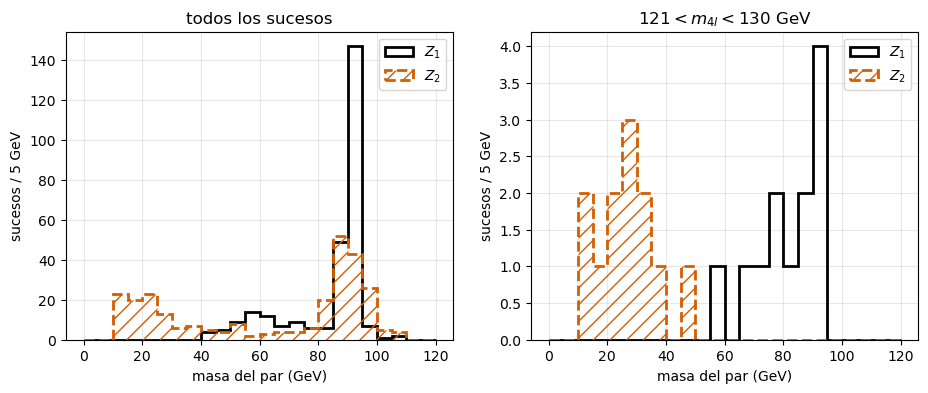

en la ventana: mZ2 máxima = 45.7 GeV; mZ1 + mZ2 <= m4l en todos los sucesos: True


In [3]:
MZ  = 91.19
pid = [datos['PID{}'.format(i)].to_numpy() for i in range(1, 5)]

mZ1 = np.full(len(datos), np.nan)
mZ2 = np.full(len(datos), np.nan)
for (a, b), (c, d) in [((0, 1), (2, 3)), ((0, 2), (1, 3)), ((0, 3), (1, 2))]:
    valido = (pid[a] == -pid[b]) & (pid[c] == -pid[d])
    mab, mcd = masa_invariante(leps[a], leps[b]), masa_invariante(leps[c], leps[d])
    z1 = np.where(np.abs(mab - MZ) < np.abs(mcd - MZ), mab, mcd)
    z2 = np.where(np.abs(mab - MZ) < np.abs(mcd - MZ), mcd, mab)
    mejor = valido & (np.isnan(mZ1) | (np.abs(z1 - MZ) < np.abs(mZ1 - MZ)))
    mZ1[mejor], mZ2[mejor] = z1[mejor], z2[mejor]

print('coinciden con mZ1, mZ2 de CMS: {:.0%}, {:.0%}'.format(
      np.mean(np.abs(mZ1 - datos['mZ1']) < 0.05), np.mean(np.abs(mZ2 - datos['mZ2']) < 0.05)))

ventana = (m4l > 121) & (m4l < 130)
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, sel, titulo in zip(axs, (np.ones(len(datos), bool), ventana),
                           ('todos los sucesos', r'$121 < m_{4l} < 130$ GeV')):
    ax.hist(mZ1[sel], bins=np.arange(0, 121, 5), histtype='step', lw=2, color='k', label=r'$Z_1$')
    ax.hist(mZ2[sel], bins=np.arange(0, 121, 5), histtype='step', lw=2, ls='--', color=COL['higgs'],
            hatch='//', label=r'$Z_2$')
    ax.set_xlabel('masa del par (GeV)'); ax.set_title(titulo); ax.grid(alpha=0.3); ax.legend()
for ax in axs:
    ax.set_ylabel('sucesos / 5 GeV')
plt.show()
print('en la ventana: mZ2 máxima = {:.1f} GeV; mZ1 + mZ2 <= m4l en todos los sucesos: {}'.format(
      mZ2[ventana].max(), np.all(mZ1 + mZ2 <= m4l + 1e-6)))

<details>
<summary><b>Solución</b></summary>

1. El emparejamiento reproduce el de CMS en el 100 % de los sucesos.
2. En el conjunto, $m_{Z_1}$ tiene un pico en $m_Z$ (casi siempre hay un $Z$ real) y $m_{Z_2}$ se extiende
   hasta más de 100 GeV (los $ZZ$ del fondo, con los dos $Z$ reales). En la ventana del Higgs, $m_{Z_2}$
   no pasa de unos 45 GeV y la mayoría está entre 15 y 35 GeV.
3. En el sistema de reposo de los cuatro leptones, cada par tiene $E_i \ge m_{Z_i}$ y
   $m_{4l} = E_1 + E_2 \ge m_{Z_1} + m_{Z_2}$ (la igualdad, si los dos pares están en reposo). Con
   $m_{4l} \simeq 125$ GeV y $m_{Z_1} \simeq 91$ GeV, $m_{Z_2} \lesssim 34$ GeV: el segundo $Z$ es
   **virtual**, como en el ejercicio 4. Cuando el $Z_1$ tampoco está en su masa (hay sucesos con
   $m_{Z_1} \sim 60$–$75$ GeV), el $Z_2$ puede ser algo mayor.

</details>

## El espectro de $m_{4l}$

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Datos frente a lo esperado</b></p>

1. Lee `higgs_4l_cms_esperados.csv` y haz el histograma de tus $m_{4l}$ con los mismos intervalos
   (de 70 a 181 GeV, de 3 GeV). Pon a cada punto su error, $\sqrt{N}$.
2. Apila los tres fondos ($ZZ$, $Z/\gamma^*$ + X, $t\bar t$) y superpón los datos. ¿Dónde está el pico
   que explica el fondo? ¿De qué es?
3. ¿Dónde hay sucesos que el fondo no explica? Añade la señal esperada de un Higgs de 125 GeV.

</div>

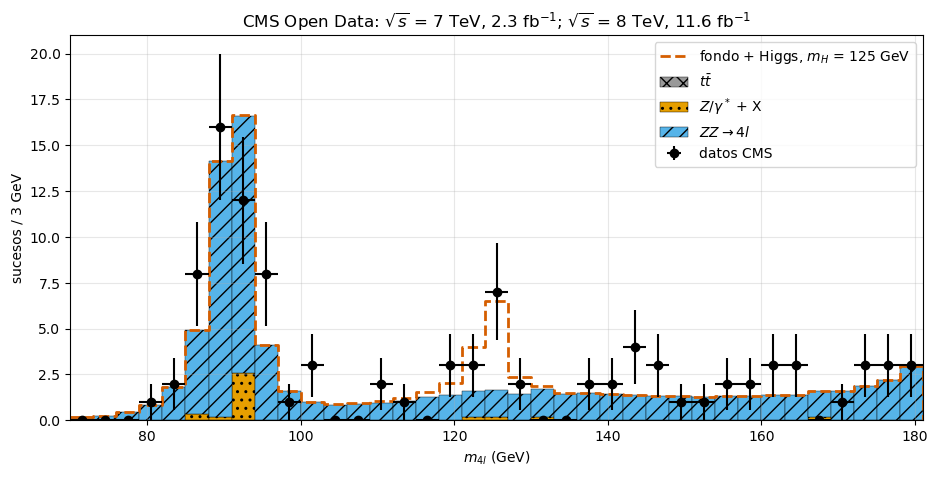

sucesos entre 70 y 181 GeV: 102 datos, 84.0 de fondo, 9.7 de señal


In [4]:
esperados = lee('higgs_4l_cms_esperados.csv')
bordes = np.append(esperados['m_min'], esperados['m_max'].iloc[-1])
centro = 0.5 * (bordes[:-1] + bordes[1:])
n, _   = np.histogram(m4l, bins=bordes)

fig, ax = plt.subplots(figsize=(11, 5))
abajo = np.zeros(len(centro))
for col, etiqueta, trama in (('ttbar', r'$t\bar t$', 'xx'), ('z_x', r'$Z/\gamma^*$ + X', '..'),
                             ('zz', r'$ZZ \to 4l$', '//')):
    ax.bar(centro, esperados[col], width=3, bottom=abajo, color=COL[col], hatch=trama,
           edgecolor='k', lw=0.3, label=etiqueta)
    abajo = abajo + esperados[col].to_numpy()
fondo = abajo.copy()
ax.step(bordes, np.append(fondo + esperados['higgs_125'], 0), where='post', color=COL['higgs'],
        lw=2, ls='--', label=r'fondo + Higgs, $m_H$ = 125 GeV')
ax.errorbar(centro, n, yerr=np.sqrt(n), xerr=1.5, fmt='o', color='k', label='datos CMS')
ax.set_xlabel(r'$m_{4l}$ (GeV)'); ax.set_ylabel('sucesos / 3 GeV')
ax.set_title(r'CMS Open Data: $\sqrt{s}$ = 7 TeV, 2.3 fb$^{-1}$; $\sqrt{s}$ = 8 TeV, 11.6 fb$^{-1}$')
ax.set_xlim(70, 181); ax.grid(alpha=0.3); ax.legend()
plt.show()

print('sucesos entre 70 y 181 GeV: {} datos, {:.1f} de fondo, {:.1f} de señal'.format(
      n.sum(), fondo.sum(), esperados['higgs_125'].sum()))

<details>
<summary><b>Solución</b></summary>

1. y 2. El fondo tiene un pico en **91 GeV**: es el propio $Z$ desintegrándose en cuatro leptones,
   $Z \to \ell + \ell^+ + \gamma^* \to 4\ell$ (un leptón del par radia un fotón virtual que da otro par).
   Los datos lo siguen bien: sirve de calibración de la escala de masas. Hacia 180 GeV empieza a subir el
   $ZZ$ con los dos $Z$ reales (umbral en $2m_Z = 182$ GeV).
3. Hay un exceso de sucesos entre 121 y 130 GeV, justo donde cae la señal esperada de un Higgs de
   125 GeV. En el resto, datos y fondo casan dentro de las fluctuaciones $\sqrt N$. La anchura del
   pico, de unos pocos GeV, es la resolución del detector; la del Higgs es de 4 MeV.

</details>

## ¿Cuánto de raro es el exceso?

Si solo hubiera fondo, el número de sucesos en la ventana seguiría una **Poisson** de media $b$, el
fondo esperado. El exceso es significativo si es muy improbable que el fondo solo dé tantos sucesos
**o más**: esa probabilidad es el **valor $p$**.

Se suele traducir a «sigmas», $Z$: la distancia a la media de una gaussiana que deja fuera la misma
probabilidad por un lado. En física de partículas, $Z = 3$ ($p = 1.3\times10^{-3}$) es un **indicio**
y $Z = 5$ ($p = 2.9\times10^{-7}$), un **descubrimiento**.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — La significación</b></p>

1. Cuenta los sucesos observados $n$, el fondo $b$ y la señal esperada $s$ en la ventana
   $121 < m_{4l} < 130$ GeV (los intervalos 121–124, 124–127 y 127–130).
2. Calcula el valor $p$ con la Poisson, $P(N \ge n \,|\, b)$, y compruébalo **simulando** un millón de
   experimentos en los que solo hay fondo. ¿A cuántas sigmas corresponde?
3. ¿Es un descubrimiento? Estima, con $Z \simeq s/\sqrt{b}$, qué luminosidad haría falta para llegar a
   $5\sigma$.
4. Compara con la figura de ATLAS del ejercicio 4 (29 $\mathrm{fb}^{-1}$ a 13.6 TeV).

</div>

ventana 121-130 GeV: n = 12, b = 4.66, s = 8.20


p (Poisson)    = 3.1e-03   ->  Z = 2.7
p (simulación) = 3.2e-03
s/sqrt(b) = 3.8;  luminosidad para 5 sigma: x1.7 = 24 fb-1


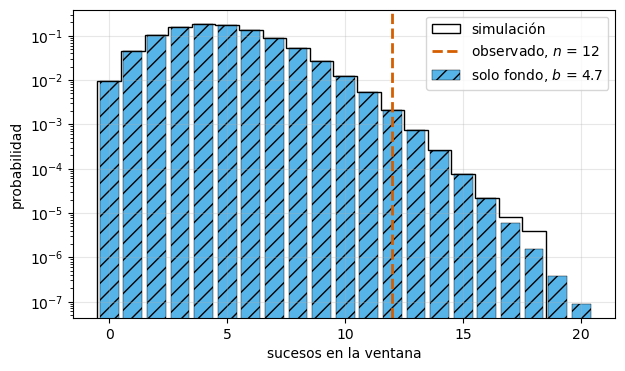

In [5]:
en_ventana = (bordes[:-1] >= 121) & (bordes[1:] <= 130)
n_obs = n[en_ventana].sum()
b     = fondo[en_ventana].sum()
s     = esperados['higgs_125'].to_numpy()[en_ventana].sum()
print('ventana 121-130 GeV: n = {}, b = {:.2f}, s = {:.2f}'.format(n_obs, b, s))

p = poisson.sf(n_obs - 1, b)                         # P(N >= n_obs | b)
rng   = np.random.default_rng(1)
toys  = rng.poisson(b, size=10**6)                    # un millón de experimentos solo con fondo
p_toy = np.mean(toys >= n_obs)
print('p (Poisson)    = {:.1e}   ->  Z = {:.1f}'.format(p, norm.isf(p)))
print('p (simulación) = {:.1e}'.format(p_toy))

Z_aprox = s / np.sqrt(b)
print('s/sqrt(b) = {:.1f};  luminosidad para 5 sigma: x{:.1f} = {:.0f} fb-1'.format(
      Z_aprox, (5 / Z_aprox)**2, (5 / Z_aprox)**2 * (2.3 + 11.6)))

fig, ax = plt.subplots(figsize=(7, 4))
ks = np.arange(0, 21)
ax.bar(ks, poisson.pmf(ks, b), color=COL['zz'], hatch='//', edgecolor='k', lw=0.3,
       label=r'solo fondo, $b$ = {:.1f}'.format(b))
ax.hist(toys, bins=ks - 0.5, density=True, histtype='step', color='k', label='simulación')
ax.axvline(n_obs, color=COL['higgs'], ls='--', lw=2, label=r'observado, $n$ = {}'.format(n_obs))
ax.set_xlabel('sucesos en la ventana'); ax.set_ylabel('probabilidad'); ax.set_yscale('log')
ax.grid(alpha=0.3); ax.legend()
plt.show()

<details>
<summary><b>Solución</b></summary>

1. $n = 12$, $b = 4.7$ y $s = 8.2$: se esperaban $b + s \simeq 13$ si el Higgs existe, y se ven 12.
2. $P(N \ge 12 \,|\, 4.7) = 3.1\times10^{-3}$ (la simulación da lo mismo), es decir,
   $Z \simeq 2.7\sigma$: un **indicio**, no un descubrimiento.
3. $s/\sqrt b = 3.8$ (la aproximación gaussiana exagera con tan pocos sucesos: la Poisson da menos).
   Como $s$ y $b$ crecen con la luminosidad $L$, $Z \propto \sqrt L$: para $5\sigma$ hace falta
   $(5/3.8)^2 \simeq 1.7$ veces más, unos 24 $\mathrm{fb}^{-1}$, y algo más con la Poisson. Por eso en julio de
   2012 CMS y ATLAS combinaron varios canales ($\gamma\gamma$ y $4\ell$): ninguno llegaba solo a $5\sigma$.
   En este cuaderno se usa, además, una fracción de los datos y una selección sencilla.
4. ATLAS, con 29 $\mathrm{fb}^{-1}$ a 13.6 TeV, ve unos 30 sucesos de exceso sobre $\simeq 17$ de fondo en la misma
   ventana. Hay el doble de luminosidad y la sección eficaz de producción del Higgs es unas 2.7 veces
   mayor a 13.6 TeV que a 8 TeV: el pico se ve solo a simple vista.

</details>

## Resumen

* La masa invariante de los cuatro leptones, $m_{4l}^2 = (\sum E)^2 - |\sum \vec p|^2$, es la masa de la
  partícula madre, sea cual sea su movimiento en el laboratorio.

* Los leptones se emparejan en dos $Z$: uno cerca de su masa y otro, $Z^*$, virtual, porque
  $m_H < 2 m_Z$.

* El fondo ($ZZ$, $Z$ + X, $t\bar t$) explica el pico del $Z$ en 91 GeV; en 121–130 GeV hay 12 sucesos
  donde el fondo da 4.7.

* Con la Poisson, $p = 3\times10^{-3}$: $2.7\sigma$, un indicio. El descubrimiento ($5\sigma$) pide más
  luminosidad o combinar canales.